In [1]:
import pandas as pd
import numpy as np
import nucml.datasets as nuc_data
from autogluon.tabular import TabularPredictor
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import logging

# Increase logging for better visibility
logging.getLogger("autogluon").setLevel(logging.INFO)

# 1. Load EXFOR with AME physics
exfor_df = nuc_data.load_exfor()
exfor_df['MT'] = pd.to_numeric(exfor_df['MT'], errors='coerce')
actinides = exfor_df[(exfor_df['MT'] == 18) & (exfor_df['Z'] >= 89)].copy()

# 2. Load RIPL/ENSDF Level Structures
ensdf_ml, _, _, _, _, _, _ = nuc_data.load_ensdf_ml(cutoff=False, append_ame=True, basic=1, num=True)
ripl_grouped = ensdf_ml.groupby(['Z', 'A']).mean().reset_index()

# 3. Merge EXFOR + RIPL
master_df = pd.merge(actinides, ripl_grouped, on=['Z', 'A'], how='left', suffixes=('_exfor', '_ripl'))

/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv
INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)
INFO:root:AME: Reading and loading Atomic Mass Evaluation files from: 
 /Users/glsw/main/NucMLClone2/AME/CSV_Files/AME_all_merged_no_NaN.csv
INFO:root:Dropping unnecessary features and one-hot encoding categorical columns...
INFO:root:Splitting dataset into training and testing...
INFO:root:Normalizing dataset...
INFO:root:Fitting new scaler.
INFO:root:Finished. Resulting dataset has 

In [7]:
# ==========================================
# REVISED: PHYSICS INTERACTION FEATURES
# ==========================================
from sklearn.preprocessing import StandardScaler

print(">>> Engineering Physics Interactions to force feature relevance...")

# 1. Log-transform Incident Energy
df_ml['Energy_Log'] = np.log10(df_ml[energy_col])

# 2. CREATE INTERACTION FEATURES (The "Physics Clues")
# These features combine Energy and Binding Energy/Sn into a single column
# This forces the model to realize they are mathematically linked.
df_ml['Energy_minus_Sn'] = df_ml['Energy_Log'] - np.log10(df_ml['S(n)_exfor'] * 1e6)
df_ml['BE_per_A'] = df_ml['Binding_Energy_exfor'] / df_ml['A']
df_ml['Z_A_Ratio'] = df_ml['Z'] / df_ml['A']

# 3. Select the final feature set
# We include the raw physics AND the interactions
physics_features = ['Z', 'A', 'Binding_Energy_exfor', 'S(n)_exfor', 'Level_Number']
interaction_features = ['Energy_minus_Sn', 'BE_per_A', 'Z_A_Ratio']
final_features = ['Energy_Log'] + physics_features + interaction_features

# 4. Standardize everything
scaler = StandardScaler()
df_ml[final_features] = scaler.fit_transform(df_ml[final_features])

print(f">>> Interaction engineering complete. Total Features: {len(final_features)}")

>>> Engineering Physics Interactions to force feature relevance...
>>> Interaction engineering complete. Total Features: 9


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [3]:
target_iso = '241Am'

# Split based on the target isotope
train_data = df_ml[df_ml['Isotope'] != target_iso][features + ['label']]
test_data = df_ml[df_ml['Isotope'] == target_iso][features + ['label']]

# Extract raw energy specifically for plotting later (to avoid KeyErrors)
E_raw_test = df_fast[df_fast['Isotope'] == target_iso][energy_col].values

print(f"Training on {len(train_data)} points. Predicting unseen {target_iso}.")

Training on 33682 points. Predicting unseen 241Am.


In [8]:
# Train with 'high_quality' to force deeper search into physics features
predictor_m1 = TabularPredictor(label='label', eval_metric='root_mean_squared_error').fit(
    train_data, 
    presets='high_quality', # 'best_quality' might be over-simplifying for speed
    hyperparameters={
        'GBM': {}, # LightGBM is good at interactions
        'XGB': {}, # XGBoost is what you used successfully before
        'NN_TORCH': {} # Neural Nets are better at finding non-linear physics
    },
    time_limit=600
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260127_132707"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:09:40 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T6000
CPU Count:          8
Memory Avail:       4.00 GB / 16.00 GB (25.0%)
Disk Space Avail:   281.59 GB / 460.43 GB (61.2%)
Presets specified: ['high_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this ri

Computing feature importance via permutation shuffling for 6 features using 573 rows with 5 shuffle sets...
	0.97s	= Expected runtime (0.19s per shuffle set)
	0.31s	= Actual runtime (Completed 5 of 5 shuffle sets)


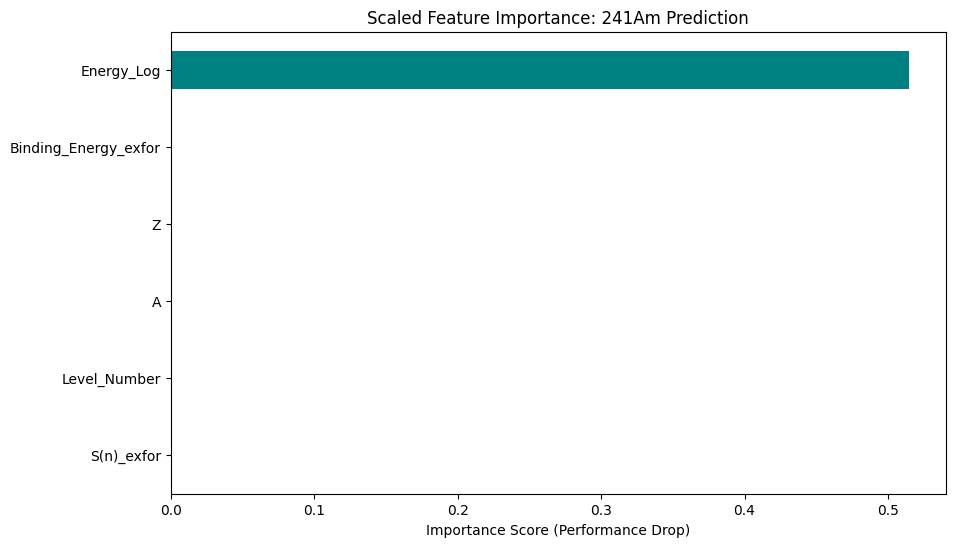

                        importance    stddev       p_value  n      p99_high  \
Energy_Log            5.145428e-01  0.008866  1.057397e-08  5  5.327981e-01   
Binding_Energy_exfor  1.424881e-09  0.000000  5.000000e-01  5  1.424881e-09   
Z                     1.394749e-09  0.000000  5.000000e-01  5  1.394749e-09   
A                     1.223637e-09  0.000000  5.000000e-01  5  1.223637e-09   
Level_Number          4.289385e-10  0.000000  5.000000e-01  5  4.289385e-10   
S(n)_exfor           -5.287810e-10  0.000000  5.000000e-01  5 -5.287810e-10   

                           p99_low  
Energy_Log            4.962876e-01  
Binding_Energy_exfor  1.424881e-09  
Z                     1.394749e-09  
A                     1.223637e-09  
Level_Number          4.289385e-10  
S(n)_exfor           -5.287810e-10  


: 

In [ ]:
# Calculate Importance on the scaled test set
importance = predictor_m1.feature_importance(test_data)

plt.figure(figsize=(10, 6))
importance['importance'].sort_values().plot(kind='barh', color='teal')
plt.title(f'Scaled Feature Importance: {target_iso} Prediction')
plt.xlabel('Importance Score (Performance Drop)')
plt.show()

print(importance)